2k: logs v: ['start', 'node_1 running done']
2k: cur_id v: start_node_1
3k: logs v: ['start', 'node_1 running done']
3k: cur_id v: start_node_1
3k: logs v: ['node_2 running done']
3k: cur_id v: start_node_1
4k: logs v: ['node_2 running done']
4k: cur_id v: start_node_1
4k: logs v: ['node_2 running done', 'node_3 running done', 'node_4 running done']
4k: cur_id v: start_node_1


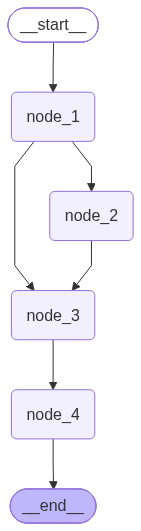

{'logs': ['node_2 running done', 'node_3 running done', 'node_4 running done', 'node_4 running done'], 'cur_id': 'start_node_1'}


In [ ]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from langgraph.types import Overwrite

class OverAllState(TypedDict):
    logs: Annotated[list[str], add]
    cur_id: str
    
def node_1(state: OverAllState) -> OverAllState:
    pre_id = state["cur_id"]
    return {
        "logs": ["node_1 running done"],
        "cur_id": pre_id + "_node_1"
    }

def node_2(state: OverAllState) -> OverAllState:
    for k,v in state.items():
        print(f"2k: {k} v: {v}")
    return {
        "logs": Overwrite(["node_2 running done"]), # type: ignore
    }

def node_3(state: OverAllState) -> OverAllState:
    for k,v in state.items():
        print(f"3k: {k} v: {v}")
    return {
        "logs":  ["node_3 running done"],
    } # type: ignore
    
def node_4(state: OverAllState) -> OverAllState:
    for k,v in state.items():
        print(f"4k: {k} v: {v}")
    return {
        "logs":  ["node_4 running done"],
    } # type: ignore
    
    
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", "node_4")
builder.add_edge("node_4", END)
graph = builder.compile()
result = graph.invoke({"logs": ["start"], "cur_id": "start"})
IMG = graph.get_graph().draw_mermaid_png()
png = Image(IMG)
with open("node_state.png", "wb") as f:
    f.write(IMG)
display(png)
print(result)
